# Action Recognition Training - Classification Model

This notebook trains a simple LSTM classifier to recognize walking vs non-walking actions from keypoint sequences.

## 1. Import Libraries

In [1]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm

## 2. Configuration

In [2]:
DATASET_DIR = "../dataset"  # Relative to Behavier_recognition folder
SEQUENCE_LENGTH = 30  # Number of consecutive valid frames
STRIDE = 15  # Sliding window stride
MIN_CONFIDENCE = 0.3  # Minimum keypoint confidence
MIN_VALID_KEYPOINTS = 8  # Minimum valid keypoints per frame (out of 12)
BATCH_SIZE = 64  # Increased from 32 for faster training
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3
K_FOLDS = 3  # Reduced from 5 (faster with large dataset)
NUM_WORKERS = 0  # Set to 0 on Windows to avoid deadlock

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():print(f"Batch Size: {BATCH_SIZE} | Num Workers: {NUM_WORKERS}")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"K-Fold CV: {K_FOLDS} folds")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
Batch Size: 64 | Num Workers: 0
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
K-Fold CV: 3 folds
GPU Memory: 6.44 GB


## 3. Define Dataset Class với Persistent Cache

### 💾 Persistent Cache System
- **Lưu cache vào disk** (file `.pkl`) sau khi load JSON lần đầu
- **Tự động load từ disk** khi chạy lại notebook (không cần đọc JSON nữa)
- **Cache filename** dựa trên config hash (seq_length, stride, min_confidence, min_valid_keypoints)
- **Tự động phát hiện** nếu có file mới cần load

### 🚀 Lợi ích:
1. **Lần chạy đầu tiên**: Load JSON → Lưu cache → Chậm (như bình thường)
2. **Các lần sau**: Load từ cache file → **Cực nhanh** (vài giây thay vì vài phút)
3. **Thay đổi config**: Tự động tạo cache file mới với hash khác
4. **Tiết kiệm thời gian**: Không cần chờ load JSON mỗi lần chạy lại notebook

### 📁 Cache directory structure:
```
cache/
  └── sequence_cache_a1b2c3d4.pkl  (hash dựa trên config)
```

Dataset với bộ lọc chất lượng frame:
- Chỉ sử dụng 12 keypoints quan trọng (vai, tay, hông, chân)
- Lọc frame theo độ tin cậy và số keypoints hợp lệ
- Tự động tìm sequences liên tục chất lượng tốt

In [3]:
class SequenceCache:
    """Cache để lưu trữ sequences đã load từ JSON files (có persistent storage)"""
    
    BODY_KEYPOINTS = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    
    def __init__(self, sequence_length=30, stride=15, min_confidence=0.3, min_valid_keypoints=8, cache_dir="cache"):
        self.sequence_length = sequence_length
        self.stride = stride
        self.min_confidence = min_confidence
        self.min_valid_keypoints = min_valid_keypoints
        self.cache = {}  # {file_path: [(sequence_array, label), ...]}
        self.cache_dir = cache_dir
        
        # Tạo cache directory nếu chưa tồn tại
        os.makedirs(cache_dir, exist_ok=True)
    
    def _is_frame_valid(self, frame):
        if not isinstance(frame, list) or len(frame) == 0:
            return False
        valid_count = 0
        for kp_idx in self.BODY_KEYPOINTS:
            if kp_idx < len(frame):
                keypoint = frame[kp_idx]
                if len(keypoint) >= 3 and keypoint[2] >= self.min_confidence:
                    valid_count += 1
        return valid_count >= self.min_valid_keypoints
    
    def _find_valid_sequences(self, frames):
        valid_sequences = []
        current_sequence = []
        for i, frame in enumerate(frames):
            if self._is_frame_valid(frame):
                current_sequence.append(i)
                if len(current_sequence) >= self.sequence_length:
                    start_idx = len(current_sequence) - self.sequence_length
                    if start_idx % self.stride == 0 or start_idx == 0:
                        valid_sequences.append(current_sequence[-self.sequence_length:])
            else:
                current_sequence = []
        return valid_sequences
    
    def _extract_keypoints(self, sequence_frames):
        keypoints_seq = []
        for frame in sequence_frames:
            frame_kps = []
            for kp_idx in self.BODY_KEYPOINTS:
                if kp_idx < len(frame):
                    keypoint = frame[kp_idx]
                    if len(keypoint) >= 3:
                        x = np.clip(keypoint[0], 0, 224)
                        y = np.clip(keypoint[1], 0, 224)
                        conf = np.clip(keypoint[2], 0, 1)
                        frame_kps.extend([x, y, conf])
                    else:
                        frame_kps.extend([0, 0, 0])
                else:
                    frame_kps.extend([0, 0, 0])
            keypoints_seq.append(frame_kps)
        
        keypoints_array = np.array(keypoints_seq, dtype=np.float32)
        keypoints_array[:, 0::3] /= 224.0
        keypoints_array[:, 1::3] /= 224.0
        return keypoints_array
    
    def load_sequences(self, data_paths, labels):
        """Load và cache sequences từ JSON files (chỉ 1 lần, có persistent storage)"""
        print(f"\n🔄 Loading sequences from {len(data_paths)} files...")
        print(f"  Settings: seq_len={self.sequence_length}, stride={self.stride}")
        print(f"  Quality: min_conf={self.min_confidence}, min_kps={self.min_valid_keypoints}")
        
        total_sequences = 0
        for path, label in tqdm(zip(data_paths, labels), total=len(data_paths), desc="Loading JSON"):
            if path in self.cache:
                continue  # Already cached
            
            try:
                with open(path, 'r') as f:
                    data = json.load(f)
                frames = data.get('frames', [])
                
                if len(frames) < self.sequence_length:
                    self.cache[path] = []
                    continue
                
                valid_seq_indices = self._find_valid_sequences(frames)
                if len(valid_seq_indices) == 0:
                    self.cache[path] = []
                    continue
                
                # Extract keypoints cho tất cả valid sequences
                file_sequences = []
                for seq_indices in valid_seq_indices:
                    sequence_frames = [frames[i] for i in seq_indices]
                    keypoints = self._extract_keypoints(sequence_frames)
                    if keypoints is not None:
                        file_sequences.append((keypoints, label))
                
                self.cache[path] = file_sequences
                total_sequences += len(file_sequences)
                
            except Exception as e:
                print(f"\n❌ Error loading {path}: {e}")
                self.cache[path] = []
        
        print(f"✅ Cached {total_sequences} sequences from {len(self.cache)} files")
        
        return total_sequences
    
    def get_sequences(self, data_paths):
        """Lấy sequences từ cache (nhanh, không đọc file)"""
        sequences = []
        labels = []
        for path in data_paths:
            if path in self.cache:
                for seq, label in self.cache[path]:
                    sequences.append(seq)
                    labels.append(label)
        return sequences, labels

class ActionDataset(Dataset):
    """Simple dataset that uses cached sequences"""
    
    def __init__(self, sequence_cache, data_paths):
        """
        Args:
            sequence_cache: SequenceCache object đã load sequences
            data_paths: List paths để lấy sequences từ cache
        """
        self.sequences, self.labels = sequence_cache.get_sequences(data_paths)
        print(f"📦 Created dataset: {len(self.sequences)} sequences")
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = torch.FloatTensor(self.sequences[idx])
        label = torch.LongTensor([self.labels[idx]])[0]
        return sequence, label

## 4. Define Model Architecture

Bi-directional LSTM với fully connected layers

In [4]:
class ActionClassifier(nn.Module):
    """Bi-directional LSTM classifier for action recognition"""
    
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=2, dropout=0.3):
        super(ActionClassifier, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bi-directional LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)  # *2 for bidirectional
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, num_classes)

        # Tải model cũ nếu có (sau khi đã khởi tạo layers)
        model_path = f"action_classifier_{hidden_size}_{num_layers}.pth"
        if os.path.exists(model_path):
            try:
                self.load_state_dict(torch.load(model_path))
                print(f"✅ Loaded existing model from {model_path}")
            except Exception as e:
                print(f"⚠️ Could not load model: {e}")
                print("   Using freshly initialized model instead.")
        else:
            print("💡 No existing model found, using new model.")
            
    def forward(self, x):
        # x shape: (batch, sequence_length, input_size)
        
        # LSTM forward pass
        lstm_out, _ = self.lstm(x)
        
        # Take the output from the last time step
        lstm_out = lstm_out[:, -1, :]
        
        # Fully connected layers
        out = self.fc1(lstm_out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out
    
    def save_model(self):
        torch.save(self.state_dict(), f"action_classifier_{self.hidden_size}_{self.num_layers}.pth")

In [5]:
# Load all dataset paths
walking_dir = os.path.join(DATASET_DIR, 'walking')
non_walking_dir = os.path.join(DATASET_DIR, 'non-walking')

data_paths = []
labels = []

# Load walking samples
if os.path.exists(walking_dir):
    for filename in os.listdir(walking_dir):
        if filename.endswith('.json'):
            data_paths.append(os.path.join(walking_dir, filename))
            labels.append(1)  # walking

# Load non-walking samples
if os.path.exists(non_walking_dir):
    for filename in os.listdir(non_walking_dir):
        if filename.endswith('.json'):
            data_paths.append(os.path.join(non_walking_dir, filename))
            labels.append(0)  # non-walking

print(f"Total files: {len(data_paths)}")
print(f"  - Walking: {sum(labels)}")
print(f"  - Non-walking: {len(labels) - sum(labels)}")

data_paths = np.array(data_paths)
labels = np.array(labels)

Total files: 6031
  - Walking: 2553
  - Non-walking: 3478


## 6. K-Fold Cross-Validation Training

Train model với K-fold CV để đánh giá độ chính xác trung bình

In [6]:
sequence_cache = None

In [7]:
# ========== BƯỚC 1: Pre-load TẤT CẢ sequences vào cache (CHỈ 1 LẦN) ==========
if sequence_cache == None:
    print("\n" + "="*80)
    print("STEP 1: PRE-LOADING ALL SEQUENCES INTO CACHE")
    print("="*80)

    sequence_cache = SequenceCache(
        sequence_length=SEQUENCE_LENGTH,
        stride=STRIDE,
        min_confidence=MIN_CONFIDENCE,
        min_valid_keypoints=MIN_VALID_KEYPOINTS
    )

    # Load tất cả files vào cache (chỉ đọc JSON 1 lần duy nhất)
    total_cached = sequence_cache.load_sequences(data_paths, labels)
    print(f"\n✅ Cache ready! Total sequences: {total_cached}")
    
    print("="*80)

# ========== BƯỚC 2: Progressive Training Across Folds ==========
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_results = []
all_histories = []

print("\n" + "="*60)
print(f"PROGRESSIVE TRAINING ACROSS {K_FOLDS} FOLDS (No Model Reset)")
print("="*60)

# Get input size from cache (tìm file có sequences hợp lệ)
input_size = None
for path in data_paths:
    sample_seq, _ = sequence_cache.get_sequences([path])
    if len(sample_seq) > 0:
        input_size = sample_seq[0].shape[1]
        break

if input_size is None:
    raise ValueError("❌ No valid sequences found in cache!")

print(f"\n{'='*60}")
print(f"INITIALIZING MODEL (ONE-TIME ONLY)")
print(f"{'='*60}")

# Create model (dùng xuyên suốt tất cả folds)
model = ActionClassifier(
    input_size=input_size,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=2,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
best_val_acc = 0.0
print(f"✅ Model initialized (will train continuously across all folds)")

# Global tracking
global_train_losses = []
global_val_losses = []
global_train_accs = []
global_val_accs = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(data_paths)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{K_FOLDS} (Continue Training)")
    print(f"{'='*60}")
    
    # Split data for this fold
    train_paths_fold = data_paths[train_idx]
    val_paths_fold = data_paths[val_idx]
    
    print(f"\nFold {fold + 1} split:")
    print(f"  Train files: {len(train_paths_fold)}")
    print(f"  Val files: {len(val_paths_fold)}")
    
    # Create datasets từ cache (NHANH - không đọc JSON)
    train_dataset = ActionDataset(sequence_cache, train_paths_fold)
    val_dataset = ActionDataset(sequence_cache, val_paths_fold)
    
    if len(train_dataset) == 0 or len(val_dataset) == 0:
        print(f"⚠️ Fold {fold + 1}: No valid sequences, skipping...")
        continue
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True, 
        num_workers=NUM_WORKERS,
        pin_memory=True if torch.cuda.is_available() else False,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=BATCH_SIZE * 2,
        shuffle=False, 
    # Training loop (tiếp tục từ model hiện tại)
        pin_memory=True if torch.cuda.is_available() else False,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    
    # Training history per fold
    fold_train_losses = []
    fold_train_accs = []
    fold_val_losses = []
    fold_val_accs = []
    
    for epoch in range(NUM_EPOCHS):
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_labels_list = []
        
        for sequences, batch_labels in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}/{NUM_EPOCHS}"):
            sequences = sequences.to(device)
            batch_labels = batch_labels.to(device)
            sequences = sequences.to(device)
            batch_labels = batch_labels.to(device)
            
            optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, batch_labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels_list.extend(batch_labels.cpu().numpy())
        
        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels_list, train_preds)
        fold_train_losses.append(train_loss)
        fold_train_accs.append(train_acc)
        global_train_losses.append(train_loss)
        global_train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_labels_list = []
        
        with torch.no_grad():
            for sequences, batch_labels in val_loader:
                sequences = sequences.to(device)
                batch_labels = batch_labels.to(device)
                
                outputs = model(sequences)
                loss = criterion(outputs, batch_labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_labels_list.extend(batch_labels.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)
        fold_val_losses.append(val_loss)
        fold_val_accs.append(val_acc)
        global_val_losses.append(val_loss)
        global_val_accs.append(val_acc)
        
        scheduler.step(val_acc)
        
        # Print progress every epoch
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
    # Store fold results
    fold_results.append({
        'fold': fold + 1,
        'best_val_acc': best_val_acc,
        'final_train_acc': fold_train_accs[-1],
        'final_val_acc': fold_val_accs[-1],
        'val_preds': val_preds,
        'val_labels': val_labels_list
    })
    
    all_histories.append({
        'train_losses': fold_train_losses,
        'val_losses': fold_val_losses,
        'train_accs': fold_train_accs,
        'val_accs': fold_val_accs

    })
    print(f"  Final Val Accuracy: {fold_val_accs[-1]:.4f}")
    print(f"💾 Best model saved to: action_classifier_progressive.pth")

    
    print(f"🏆 Best validation accuracy achieved: {best_val_acc:.4f}")

    print(f"\nFold {fold + 1} Results:")
    # Print classification report for this foldprint(f"📊 Total training iterations: {len(global_train_accs)} epochs")

    print(f"  Current Best Val Accuracy: {best_val_acc:.4f}")
    print(f"\nFold {fold + 1} Classification Report:")
    print(f"\n✅ Model trained continuously across {K_FOLDS} folds")

    print(f"  Final Train Accuracy: {fold_train_accs[-1]:.4f}")
    print(classification_report(val_labels_list, val_preds,
        target_names=['Non-Walking', 'Walking'],
        zero_division=0))
    print("\n" + "="*60)

    print(f"\nFold {fold + 1} Classification Report:")


    print(classification_report(val_labels_list, val_preds, target_names=['Non-Walking', 'Walking'],
        zero_division=0))


STEP 1: PRE-LOADING ALL SEQUENCES INTO CACHE

🔄 Loading sequences from 6031 files...
  Settings: seq_len=30, stride=15
  Quality: min_conf=0.3, min_kps=8


Loading JSON:   0%|          | 0/6031 [00:00<?, ?it/s]

Loading JSON: 100%|██████████| 6031/6031 [06:49<00:00, 14.73it/s] 



✅ Cached 45901 sequences from 6031 files

✅ Cache ready! Total sequences: 45901

PROGRESSIVE TRAINING ACROSS 3 FOLDS (No Model Reset)

INITIALIZING MODEL (ONE-TIME ONLY)
✅ Loaded existing model from action_classifier_128_2.pth
✅ Loaded existing model from action_classifier_128_2.pth
✅ Model initialized (will train continuously across all folds)

FOLD 1/3 (Continue Training)

Fold 1 split:
  Train files: 4020
  Val files: 2011
📦 Created dataset: 30772 sequences
📦 Created dataset: 15129 sequences
✅ Model initialized (will train continuously across all folds)

FOLD 1/3 (Continue Training)

Fold 1 split:
  Train files: 4020
  Val files: 2011
📦 Created dataset: 30772 sequences
📦 Created dataset: 15129 sequences


Fold 1 Epoch 1/50: 100%|██████████| 481/481 [00:03<00:00, 142.46it/s]

Fold 1 Epoch 2/50: 100%|██████████| 481/481 [00:02<00:00, 167.94it/s]

Fold 1 Epoch 3/50: 100%|██████████| 481/481 [00:02<00:00, 170.78it/s]

Fold 1 Epoch 4/50: 100%|██████████| 481/481 [00:02<00:00, 170.89it/s]

Fold 1 Epoch 5/50: 100%|██████████| 481/481 [00:02<00:00, 171.55it/s]

Fold 1 Epoch 6/50: 100%|██████████| 481/481 [00:02<00:00, 169.30it/s]

Fold 1 Epoch 7/50: 100%|██████████| 481/481 [00:02<00:00, 169.09it/s]

Fold 1 Epoch 8/50: 100%|██████████| 481/481 [00:02<00:00, 171.84it/s]

Fold 1 Epoch 9/50: 100%|██████████| 481/481 [00:02<00:00, 169.51it/s]

Fold 1 Epoch 10/50: 100%|██████████| 481/481 [00:02<00:00, 168.17it/s]



...

Epoch 30/50 - Train Loss: 0.0961, Train Acc: 0.9650, Val Loss: 0.0417, Val Acc: 0.9873


Fold 3 Epoch 31/50: 100%|██████████| 470/470 [00:04<00:00, 109.16it/s]

Fold 3 Epoch 32/50: 100%|██████████| 470/470 [00:04<00:00, 104.08it/s]

Fold 3 Epoch 33/50: 100%|██████████| 470/470 [00:03<00:00, 117.71it/s]

Fold 3 Epoch 34/50: 100%|██████████| 470/470 [00:03<00:00, 150.04it/s]

Fold 3 Epoch 35/50: 100%|██████████| 470/470 [00:03<00:00, 146.09it/s]

Fold 3 Epoch 36/50: 100%|██████████| 470/470 [00:04<00:00, 107.83it/s]

Fold 3 Epoch 37/50: 100%|██████████| 470/470 [00:04<00:00, 114.97it/s]

Fold 3 Epoch 38/50: 100%|██████████| 470/470 [00:03<00:00, 146.89it/s]

Fold 3 Epoch 39/50: 100%|██████████| 470/470 [00:03<00:00, 140.37it/s]

Fold 3 Epoch 40/50: 100%|██████████| 470/470 [00:03<00:00, 144.31it/s]



Epoch 40/50 - Train Loss: 0.0949, Train Acc: 0.9638, Val Loss: 0.0418, Val Acc: 0.9873


Fold 3 Epoch 41/50: 100%|██████████| 470/470 [00:03<00:00, 136.91it/s]

Fold 3 Epoch 42/50: 100%|██████████| 470/470 [00:03<00:00, 137.36it/s]

Fold 3 Epoch 43/50: 100%|██████████| 470/470 [00:03<00:00, 134.72it/s]

Fold 3 Epoch 44/50: 100%|██████████| 470/470 [00:03<00:00, 155.24it/s]

Fold 3 Epoch 45/50: 100%|██████████| 470/470 [00:03<00:00, 151.90it/s]

Fold 3 Epoch 46/50: 100%|██████████| 470/470 [00:03<00:00, 152.70it/s]

Fold 3 Epoch 47/50: 100%|██████████| 470/470 [00:03<00:00, 153.81it/s]

Fold 3 Epoch 48/50: 100%|██████████| 470/470 [00:03<00:00, 127.93it/s]

Fold 3 Epoch 49/50: 100%|██████████| 470/470 [00:05<00:00, 92.20it/s] 

Fold 3 Epoch 50/50: 100%|██████████| 470/470 [00:06<00:00, 71.04it/s]



Epoch 50/50 - Train Loss: 0.0948, Train Acc: 0.9647, Val Loss: 0.0418, Val Acc: 0.9873
  Final Val Accuracy: 0.9873
💾 Best model saved to: action_classifier_progressive.pth
🏆 Best validation accuracy achieved: 0.0000

Fold 3 Results:
  Current Best Val Accuracy: 0.0000

Fold 3 Classification Report:

✅ Model trained continuously across 3 folds
  Final Train Accuracy: 0.9647
              precision    recall  f1-score   support

 Non-Walking       0.99      0.98      0.99      8889
     Walking       0.98      0.99      0.99      6960

    accuracy                           0.99     15849
   macro avg       0.99      0.99      0.99     15849
weighted avg       0.99      0.99      0.99     15849



Fold 3 Classification Report:
              precision    recall  f1-score   support

 Non-Walking       0.99      0.98      0.99      8889
     Walking       0.98      0.99      0.99      6960

    accuracy                           0.99     15849
   macro avg       0.99      0.99      0.99   

## 5. Trực quan hóa kết quả

In [8]:
# Calculate average metrics across all folds
avg_best_val_acc = np.mean([r['best_val_acc'] for r in fold_results])
avg_final_train_acc = np.mean([r['final_train_acc'] for r in fold_results])
avg_final_val_acc = np.mean([r['final_val_acc'] for r in fold_results])

std_best_val_acc = np.std([r['best_val_acc'] for r in fold_results])
std_final_val_acc = np.std([r['final_val_acc'] for r in fold_results])

print("\n" + "="*60)
print("AVERAGE RESULTS ACROSS ALL FOLDS")
print("="*60)
print(f"\nBest Validation Accuracy:")
print(f"  Mean: {avg_best_val_acc:.4f} ± {std_best_val_acc:.4f}")
print(f"\nFinal Training Accuracy:")
print(f"  Mean: {avg_final_train_acc:.4f}")
print(f"\nFinal Validation Accuracy:")
print(f"  Mean: {avg_final_val_acc:.4f} ± {std_final_val_acc:.4f}")

print(f"\n\nPer-fold results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: Best Val Acc = {r['best_val_acc']:.4f}")


AVERAGE RESULTS ACROSS ALL FOLDS

Best Validation Accuracy:
  Mean: 0.0000 ± 0.0000

Final Training Accuracy:
  Mean: 0.9735

Final Validation Accuracy:
  Mean: 0.9655 ± 0.0256


Per-fold results:
  Fold 1: Best Val Acc = 0.0000
  Fold 2: Best Val Acc = 0.0000
  Fold 3: Best Val Acc = 0.0000


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21472\4019788305.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([best_accs], labels=['Best Val Acc'])


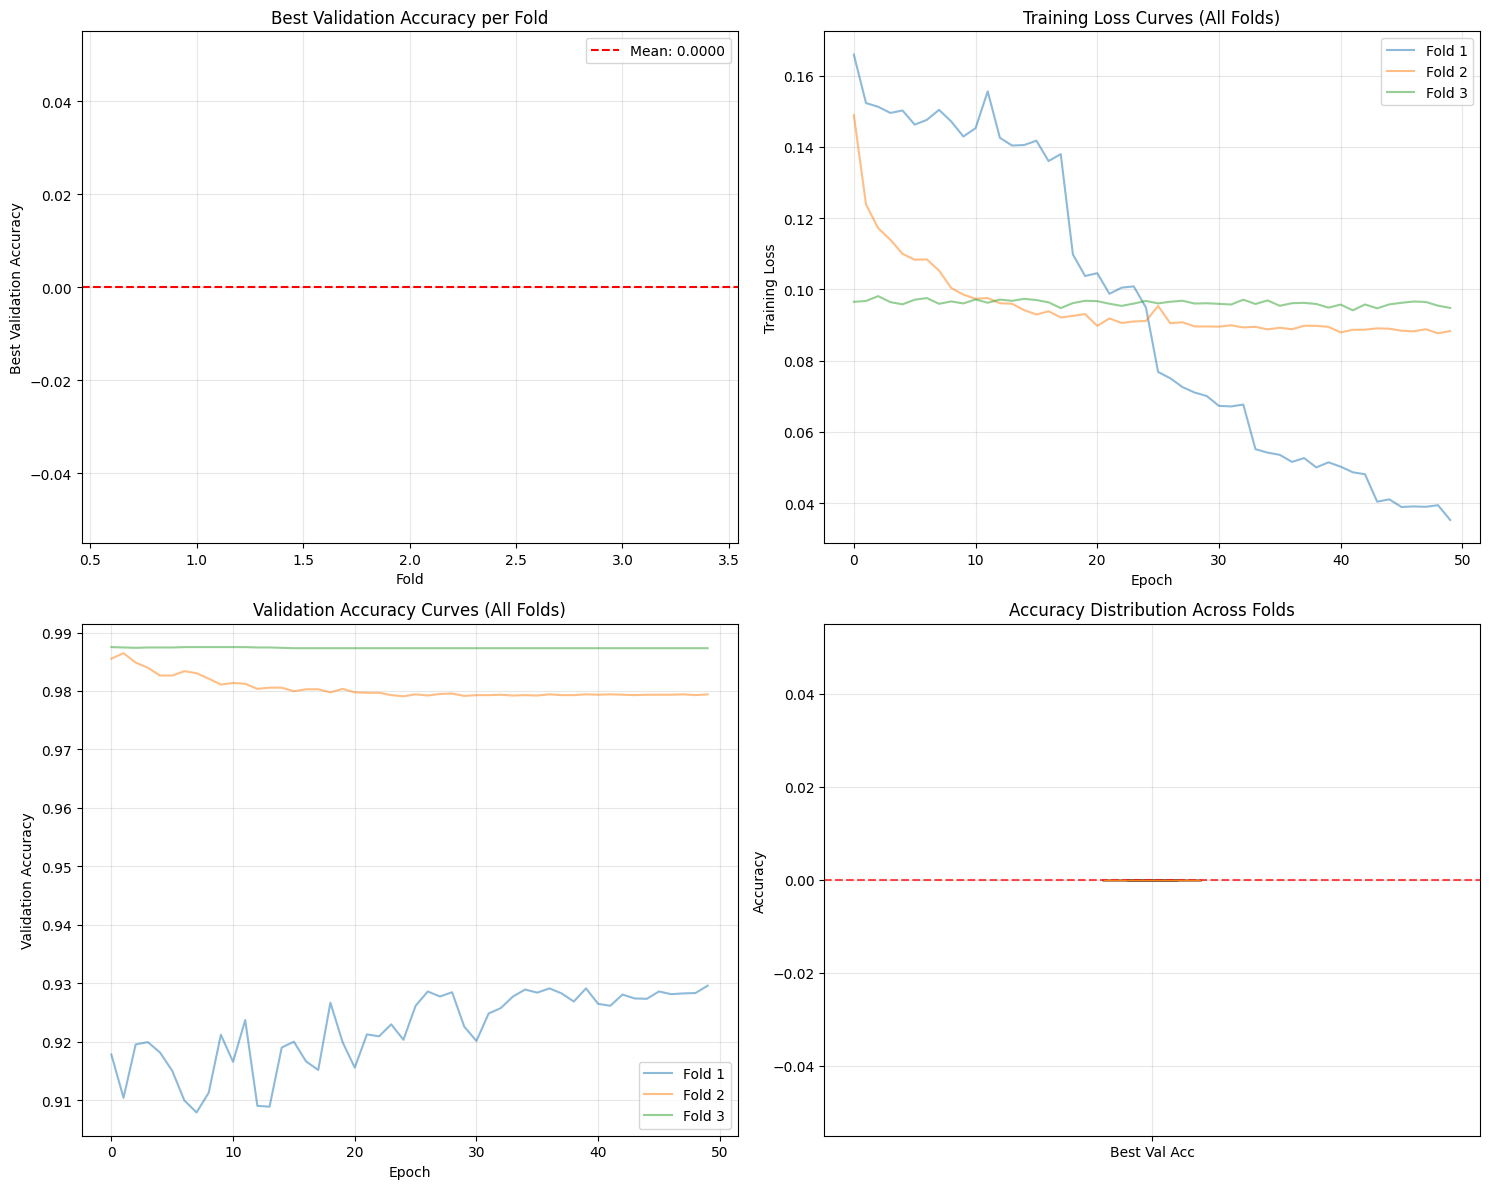


Visualization saved to 'kfold_results.png'


In [9]:
# Visualize K-fold results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Per-fold best validation accuracy
fold_nums = [r['fold'] for r in fold_results]
best_accs = [r['best_val_acc'] for r in fold_results]

axes[0, 0].bar(fold_nums, best_accs, color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=avg_best_val_acc, color='red', linestyle='--', label=f'Mean: {avg_best_val_acc:.4f}')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('Best Validation Accuracy')
axes[0, 0].set_title('Best Validation Accuracy per Fold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training curves for all folds
for i, h in enumerate(all_histories):
    axes[0, 1].plot(h['train_losses'], alpha=0.5, label=f"Fold {i+1}")
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Training Loss')
axes[0, 1].set_title('Training Loss Curves (All Folds)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Validation accuracy curves
for i, h in enumerate(all_histories):
    axes[1, 0].plot(h['val_accs'], alpha=0.5, label=f"Fold {i+1}")
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Accuracy')
axes[1, 0].set_title('Validation Accuracy Curves (All Folds)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Accuracy distribution
axes[1, 1].boxplot([best_accs], labels=['Best Val Acc'])
axes[1, 1].axhline(y=avg_best_val_acc, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Accuracy Distribution Across Folds')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kfold_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to 'kfold_results.png'")

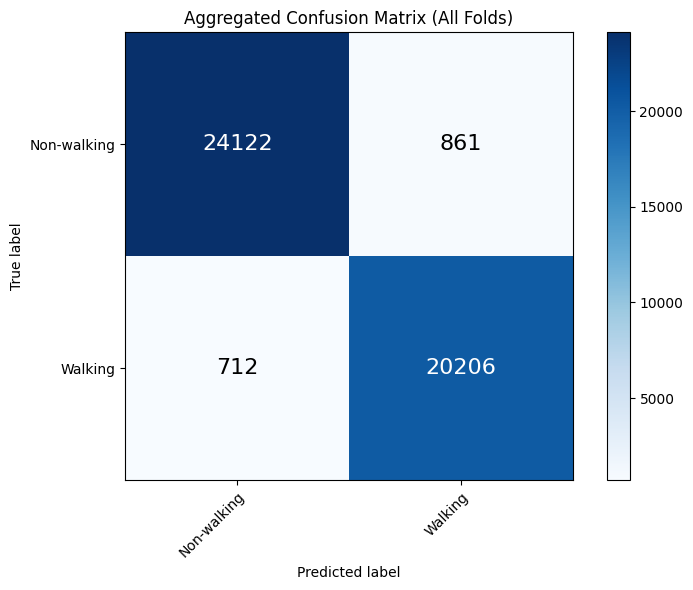


Overall Classification Report (All Folds Aggregated):
              precision    recall  f1-score   support

 Non-walking     0.9713    0.9655    0.9684     24983
     Walking     0.9591    0.9660    0.9625     20918

    accuracy                         0.9657     45901
   macro avg     0.9652    0.9657    0.9655     45901
weighted avg     0.9658    0.9657    0.9657     45901


K-FOLD CROSS-VALIDATION COMPLETE!

Final Result: 0.0000 ± 0.0000

Best performing fold: Fold 1
  Accuracy: 0.0000

Models saved:
  - action_classifier_fold1.pth
  - action_classifier_fold2.pth
  - action_classifier_fold3.pth


In [10]:
# Aggregate confusion matrix across all folds
from sklearn.metrics import confusion_matrix

# Collect all predictions and true labels
all_true = []
all_pred = []

for r in fold_results:
    all_true.extend(r['val_labels'])
    all_pred.extend(r['val_preds'])

# Calculate overall confusion matrix
cm = confusion_matrix(all_true, all_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Set labels
class_names = ['Non-walking', 'Walking']
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names, yticklabels=class_names,
       title='Aggregated Confusion Matrix (All Folds)',
       ylabel='True label',
       xlabel='Predicted label')

# Rotate the tick labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16)

plt.tight_layout()
plt.savefig('confusion_matrix_kfold.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overall metrics
from sklearn.metrics import classification_report
print("\nOverall Classification Report (All Folds Aggregated):")
print(classification_report(all_true, all_pred, target_names=class_names, digits=4))

print("\n" + "="*60)
print("K-FOLD CROSS-VALIDATION COMPLETE!")
print("="*60)
print(f"\nFinal Result: {avg_best_val_acc:.4f} ± {std_best_val_acc:.4f}")
print(f"\nBest performing fold: Fold {fold_results[np.argmax(best_accs)]['fold']}")
print(f"  Accuracy: {max(best_accs):.4f}")
print(f"\nModels saved:")
for i in range(K_FOLDS):
    print(f"  - action_classifier_fold{i+1}.pth")

In [11]:
# Lưu model cuối cùng sau khi huấn luyện xong
model.save_model()